# Practical Exam — Data Science & AI/ML (Set C)
**Student:** replace with your name/ID  
Run all cells in order. This notebook is a runnable starter aligned to the supplied practical brief.

In [1]:
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report,
                             roc_auc_score, RocCurveDisplay)
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import joblib

ROOT = Path.cwd()
if not (ROOT / "data").exists():
    ROOT = ROOT.parent
DATA = ROOT / "data" / "raw" / "campaign_response.csv"
FIG = ROOT / "outputs" / "figures"
MODELS = ROOT / "models"
FIG.mkdir(parents=True, exist_ok=True)
MODELS.mkdir(parents=True, exist_ok=True)
SEED = 42

## 1. Load and audit data

In [2]:
if not DATA.exists():
    print("Dataset not found. Run: python src/generate_data.py")
    raise FileNotFoundError(DATA)
df = pd.read_csv(DATA)
display(df.head())
print("Shape:", df.shape)
display(df.info())
display(df.isna().sum().to_frame("missing"))
print("Duplicate rows:", df.duplicated().sum())
display(df.describe(include="all").T)

,customer_id,age,annual_income,tenure_years,web_visits,email_opens,previous_purchases,channel,region,responded
0,10001,22,74463.0,15,4,6,1,Social,South,0
1,10002,59,47455.0,8,9,4,0,Web,South,0
2,10003,52,58542.0,10,5,4,3,Email,East,1
3,10004,41,12000.0,9,3,1,1,Email,West,0
4,10005,40,31186.0,15,8,6,3,Email,South,0


Shape: (1200, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   customer_id         1200 non-null   int64  
 1   age                 1200 non-null   int64  
 2   annual_income       1200 non-null   float64
 3   tenure_years        1200 non-null   int64  
 4   web_visits          1200 non-null   int64  
 5   email_opens         1200 non-null   int64  
 6   previous_purchases  1200 non-null   int64  
 7   channel             1200 non-null   object 
 8   region              1200 non-null   object 
 9   responded           1200 non-null   int64  
dtypes: float64(1), int64(7), object(2)
memory usage: 93.9+ KB


None

,missing
customer_id,0
age,0
annual_income,0
tenure_years,0
web_visits,0
email_opens,0
previous_purchases,0
channel,0
region,0
responded,0


Duplicate rows: 0


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customer_id,1200.0,NaN,NaN,NaN,10600.5,346.554469,10001.0,10300.75,10600.5,10900.25,11200.0
age,1200.0,NaN,NaN,NaN,44.225833,15.239807,18.0,31.0,44.0,58.0,70.0
annual_income,1200.0,NaN,NaN,NaN,51232.354167,18127.9213,12000.0,39145.5,51723.5,63078.75,109219.0
tenure_years,1200.0,NaN,NaN,NaN,7.284167,4.618209,0.0,3.0,7.0,11.0,15.0
web_visits,1200.0,NaN,NaN,NaN,3.983333,2.019849,0.0,3.0,4.0,5.0,14.0
email_opens,1200.0,NaN,NaN,NaN,2.986667,1.757098,0.0,2.0,3.0,4.0,11.0
previous_purchases,1200.0,NaN,NaN,NaN,2.0475,1.416068,0.0,1.0,2.0,3.0,8.0
channel,1200,4,Email,494,NaN,NaN,NaN,NaN,NaN,NaN,NaN
region,1200,4,South,321,NaN,NaN,NaN,NaN,NaN,NaN,NaN
responded,1200.0,NaN,NaN,NaN,0.5925,0.491574,0.0,0.0,1.0,1.0,1.0


## 2. Descriptive statistics and plots

,mean,median,std,min,max
age,44.225833,44.0,15.239807,18.0,70.0
annual_income,51232.354167,51723.5,18127.921300,12000.0,109219.0
tenure_years,7.284167,7.0,4.618209,0.0,15.0
web_visits,3.983333,4.0,2.019849,0.0,14.0
email_opens,2.986667,3.0,1.757098,0.0,11.0
previous_purchases,2.047500,2.0,1.416068,0.0,8.0
responded,0.592500,1.0,0.491574,0.0,1.0


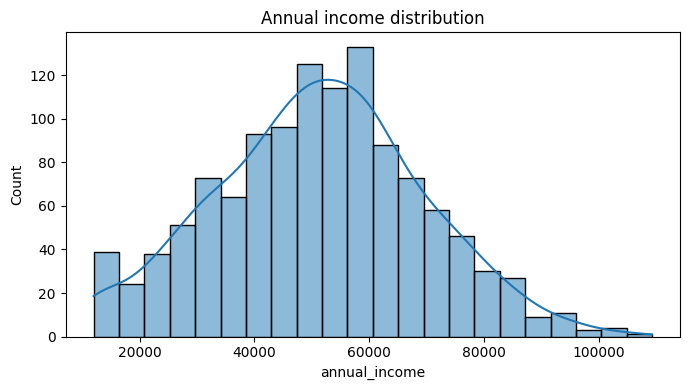

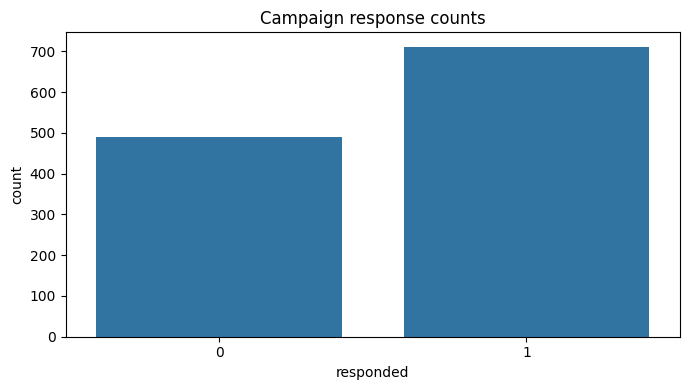

In [3]:
numeric = df.select_dtypes(include=np.number).columns.drop("customer_id", errors="ignore")
display(df[numeric].agg(["mean","median","std","min","max"]).T)
fig, ax = plt.subplots(figsize=(7,4))
sns.histplot(df["annual_income"], kde=True, ax=ax)
ax.set_title("Annual income distribution")
plt.tight_layout()
plt.savefig(FIG/"income_distribution.png", dpi=150)
plt.show()

fig, ax = plt.subplots(figsize=(7,4))
sns.countplot(data=df, x="responded", ax=ax)
ax.set_title("Campaign response counts")
plt.tight_layout()
plt.savefig(FIG/"response_counts.png", dpi=150)
plt.show()

### Statistical inference example

In [4]:
# Compare annual income for responders vs non-responders (Welch's t-test)
yes = df.loc[df.responded == 1, "annual_income"]
no = df.loc[df.responded == 0, "annual_income"]
test = stats.ttest_ind(yes, no, equal_var=False)
print(f"Welch t statistic={test.statistic:.3f}, p-value={test.pvalue:.5f}")
print("Interpret the p-value using your chosen significance level; association is not causation.")

Welch t statistic=5.353, p-value=0.00000
Interpret the p-value using your chosen significance level; association is not causation.


## 3. Preprocessing and feature engineering

In [5]:
# Drop identifier; keep target separate
target = "responded"
X = df.drop(columns=[target, "customer_id"])
y = df[target]
numeric_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(exclude=np.number).columns.tolist()

numeric_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scale", StandardScaler())
])
categorical_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])
preprocess = ColumnTransformer([
    ("num", numeric_pipe, numeric_features),
    ("cat", categorical_pipe, categorical_features)
])
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)
print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (960, 8) Test: (240, 8)


## 4. Supervised learning

In [6]:
models = {
    "Dummy baseline": DummyClassifier(strategy="most_frequent"),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=SEED),
    "Decision Tree": DecisionTreeClassifier(max_depth=6, random_state=SEED),
    "Random Forest": RandomForestClassifier(n_estimators=250, min_samples_leaf=3,
                                             random_state=SEED, n_jobs=-1)
}
fitted = {}
rows = []
for name, estimator in models.items():
    pipe = Pipeline([("prep", preprocess), ("model", estimator)])
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    prob = pipe.predict_proba(X_test)[:,1] if hasattr(pipe[-1], "predict_proba") else None
    fitted[name] = pipe
    rows.append({
        "model": name,
        "accuracy": accuracy_score(y_test, pred),
        "precision": precision_score(y_test, pred, zero_division=0),
        "recall": recall_score(y_test, pred, zero_division=0),
        "f1": f1_score(y_test, pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, prob) if prob is not None else np.nan
    })
results = pd.DataFrame(rows).sort_values("model")
display(results)

,model,accuracy,precision,recall,f1,roc_auc
2,Decision Tree,0.562500,0.603352,0.760563,0.672897,0.562949
0,Dummy baseline,0.591667,0.591667,1.000000,0.743455,0.500000
1,Logistic Regression,0.633333,0.650000,0.823944,0.726708,0.647815
3,Random Forest,0.604167,0.629834,0.802817,0.705882,0.621730


              precision    recall  f1-score   support

           0       0.53      0.32      0.39        98
           1       0.63      0.80      0.71       142

    accuracy                           0.60       240
   macro avg       0.58      0.56      0.55       240
weighted avg       0.59      0.60      0.58       240



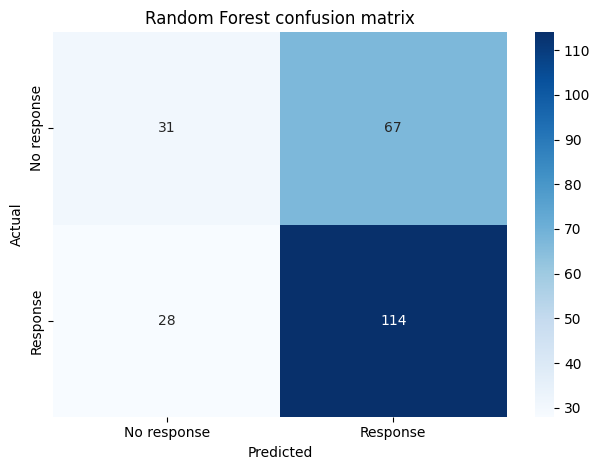

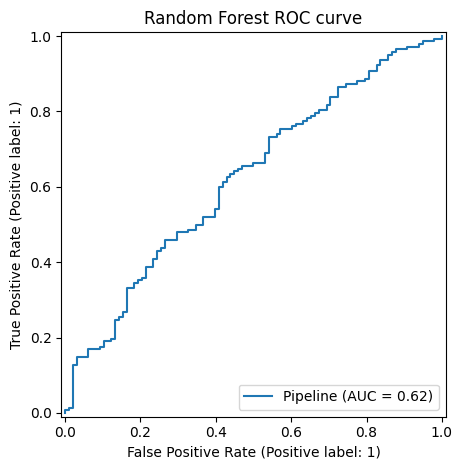

Saved model.


In [7]:
# Inspect one model's confusion matrix and report
chosen_name = "Random Forest"
chosen = fitted[chosen_name]
pred = chosen.predict(X_test)
print(classification_report(y_test, pred, zero_division=0))
cm = confusion_matrix(y_test, pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No response","Response"],
            yticklabels=["No response","Response"])
plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.title(f"{chosen_name} confusion matrix")
plt.tight_layout(); plt.savefig(FIG/"confusion_matrix.png", dpi=150); plt.show()
if hasattr(chosen[-1], "predict_proba"):
    RocCurveDisplay.from_estimator(chosen, X_test, y_test)
    plt.title(f"{chosen_name} ROC curve")
    plt.tight_layout(); plt.savefig(FIG/"roc_curve.png", dpi=150); plt.show()
joblib.dump(chosen, MODELS/"campaign_response_model.joblib")
print("Saved model.")

## 5. Unsupervised learning — K-Means

,k,inertia,silhouette
0,2,6276.293370,0.129772
1,3,5673.461098,0.124083
2,4,5222.979555,0.124591
3,5,4821.348492,0.129495
4,6,4469.570581,0.133192


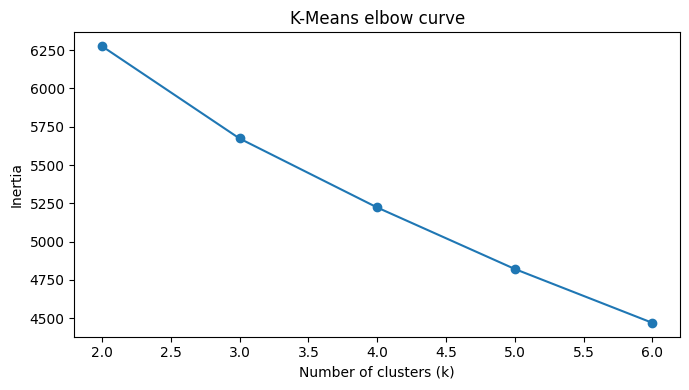

,age,annual_income,tenure_years,web_visits,email_opens,previous_purchases,responded
cluster,,,,,,,
0,52.89,52555.48,12.58,3.49,3.12,1.50,0.68
1,56.48,45340.56,3.65,3.37,2.23,1.56,0.52
2,36.53,45861.50,5.42,3.45,5.58,1.81,0.58
3,27.25,55434.90,7.09,3.46,1.96,1.90,0.48
4,46.89,52118.45,7.56,3.45,2.96,4.57,0.72
5,46.61,55301.79,6.48,7.37,2.89,1.65,0.62


['c:\\ds-aiml-set-c-project\\ds-aiml-set-c-YOUR-STUDENT-ID\\models\\kmeans_model.joblib']

In [8]:
# Cluster customer behavior using numeric features only; scale before clustering
cluster_features = ["age","annual_income","tenure_years","web_visits",
                    "email_opens","previous_purchases"]
cluster_data = df[cluster_features].copy()
cluster_scaled = StandardScaler().fit_transform(cluster_data)
scores = []
for k in range(2, 7):
    km = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    labels = km.fit_predict(cluster_scaled)
    scores.append({"k": k, "inertia": km.inertia_,
                   "silhouette": silhouette_score(cluster_scaled, labels)})
cluster_scores = pd.DataFrame(scores)
display(cluster_scores)
fig, ax = plt.subplots(figsize=(7,4))
ax.plot(cluster_scores.k, cluster_scores.inertia, marker="o")
ax.set(xlabel="Number of clusters (k)", ylabel="Inertia", title="K-Means elbow curve")
plt.tight_layout(); plt.savefig(FIG/"kmeans_elbow.png", dpi=150); plt.show()

best_k = int(cluster_scores.loc[cluster_scores.silhouette.idxmax(), "k"])
km = KMeans(n_clusters=best_k, random_state=SEED, n_init=10)
df["cluster"] = km.fit_predict(cluster_scaled)
display(df.groupby("cluster")[cluster_features + ["responded"]].mean().round(2))
joblib.dump(km, MODELS/"kmeans_model.joblib")

## 6. ANN / deep learning (optional TensorFlow)

Epoch 1/120
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.5599 - loss: 0.8073 - precision: 0.6128 - recall: 0.7419 - val_accuracy: 0.5312 - val_loss: 0.6917 - val_precision: 0.5972 - val_recall: 0.4135
Epoch 2/120
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5859 - loss: 0.7100 - precision: 0.6594 - recall: 0.6538 - val_accuracy: 0.4688 - val_loss: 0.6959 - val_precision: 0.5625 - val_recall: 0.0865
Epoch 3/120
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5911 - loss: 0.6934 - precision: 0.6951 - recall: 0.5785 - val_accuracy: 0.4792 - val_loss: 0.6934 - val_precision: 0.6250 - val_recall: 0.0962
Epoch 4/120
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6055 - loss: 0.6613 - precision: 0.7201 - recall: 0.5699 - val_accuracy: 0.4844 - val_loss: 0.6902 - val_precision: 0.5862 - val_recall: 0.1635
Epoch 5/120
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6263 - loss: 0.6452 - precision: 0.7367 - recall: 0.5957 - val_accuracy: 0.4896 - val_loss: 0.6849 

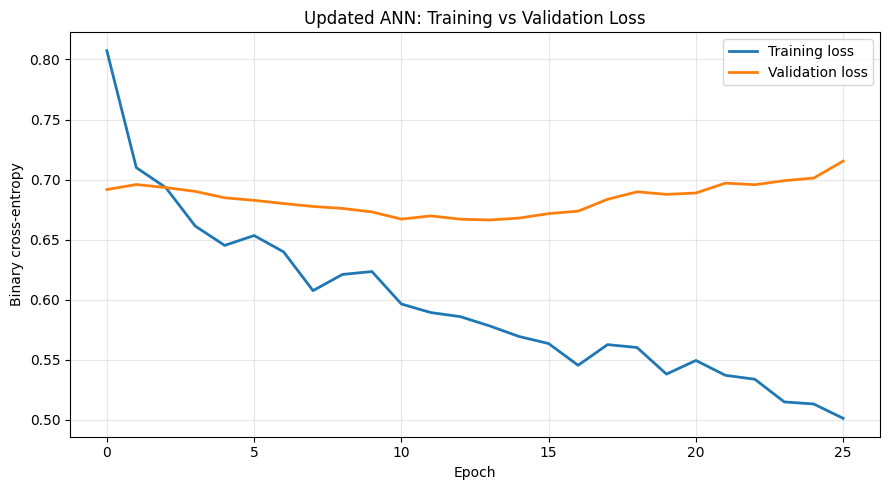

In [9]:
# Updated ANN architecture with additional Dense layers
try:
    import tensorflow as tf
    from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                                 f1_score, roc_auc_score, classification_report,
                                 confusion_matrix)
    from sklearn.utils.class_weight import compute_class_weight

    tf.keras.utils.set_random_seed(SEED)

    # Fit preprocessing on training data only
    Xtr = preprocess.fit_transform(X_train)
    Xte = preprocess.transform(X_test)
    if hasattr(Xtr, "toarray"):
        Xtr = Xtr.toarray()
    if hasattr(Xte, "toarray"):
        Xte = Xte.toarray()
    Xtr = np.asarray(Xtr, dtype="float32")
    Xte = np.asarray(Xte, dtype="float32")

    classes = np.unique(y_train)
    weights = compute_class_weight(class_weight="balanced",
                                   classes=classes, y=y_train)
    class_weight = dict(zip(classes, weights))

    ann = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(Xtr.shape[1],)),
        tf.keras.layers.Dense(128, activation="relu"),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Dropout(0.20),
        tf.keras.layers.Dense(64, activation="relu"),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Dropout(0.20),
        tf.keras.layers.Dense(32, activation="relu"),
        tf.keras.layers.Dense(16, activation="relu"),
        tf.keras.layers.Dense(1, activation="sigmoid")
    ])

    ann.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
        loss="binary_crossentropy",
        metrics=["accuracy",
                 tf.keras.metrics.Precision(name="precision"),
                 tf.keras.metrics.Recall(name="recall")]
    )

    early = tf.keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=12, restore_best_weights=True
    )

    history = ann.fit(
        Xtr, y_train,
        validation_split=0.2,
        epochs=120,
        batch_size=32,
        callbacks=[early],
        class_weight=class_weight,
        verbose=1
    )

    prob = ann.predict(Xte, verbose=0).ravel()
    ann_pred = (prob >= 0.5).astype(int)

    print("ANN Accuracy:", accuracy_score(y_test, ann_pred))
    print("Precision:", precision_score(y_test, ann_pred, zero_division=0))
    print("Recall:", recall_score(y_test, ann_pred, zero_division=0))
    print("F1 Score:", f1_score(y_test, ann_pred, zero_division=0))
    print("ROC-AUC:", roc_auc_score(y_test, prob))
    print(classification_report(y_test, ann_pred, zero_division=0))
    print("Confusion matrix:\\n", confusion_matrix(y_test, ann_pred))

    plt.figure(figsize=(9, 5))
    plt.plot(history.history["loss"], label="Training loss", linewidth=2)
    plt.plot(history.history["val_loss"], label="Validation loss", linewidth=2)
    plt.title("Updated ANN: Training vs Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Binary cross-entropy")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(FIG / "ann_loss_curve.png", dpi=150)
    plt.show()

    ann.save(MODELS / "campaign_response_ann_updated.keras")

except ImportError:
    print("TensorFlow is not installed. Install it separately to run the ANN section.")


## 7. Findings and submission checklist
Write your own evidence-based observations after running the notebook:
- Which variables differ across response groups?
- What do the test metrics and confusion matrix show? Consider class imbalance.
- What practical patterns distinguish the K-Means segments?
- Compare the ANN with the baseline and other models using the same test split.

Before submission, verify that all cells run, figures are saved, and reported values match the notebook output. Do not claim a target accuracy in advance.

## 8. Model comparison visualization

,accuracy,precision,recall,f1,roc_auc
model,,,,,
Decision Tree,0.562,0.603,0.761,0.673,0.563
Dummy baseline,0.592,0.592,1.000,0.743,0.500
Logistic Regression,0.633,0.650,0.824,0.727,0.648
Random Forest,0.604,0.630,0.803,0.706,0.622


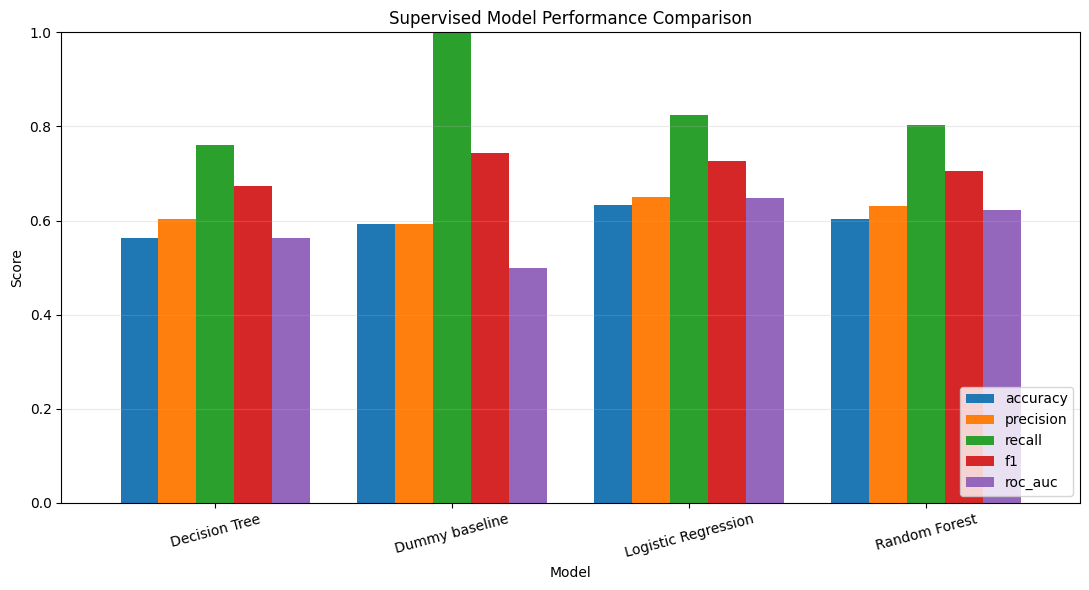

In [10]:
# Compare the supervised models using the metrics calculated above
metric_columns = ["accuracy", "precision", "recall", "f1", "roc_auc"]
comparison = results.set_index("model")[metric_columns]
display(comparison.round(3))

ax = comparison.plot(kind="bar", figsize=(11, 6), ylim=(0, 1),
                     width=0.8, rot=15)
ax.set_title("Supervised Model Performance Comparison")
ax.set_ylabel("Score")
ax.set_xlabel("Model")
ax.grid(axis="y", alpha=0.25)
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig(FIG / "model_comparison.png", dpi=150)
plt.show()


## 9. Example: predict response for a new customer

In [11]:
# Example values must use the same feature columns as X.
# Change these values to test different customer profiles.
new_customer = pd.DataFrame([{
    "age": 35,
    "annual_income": 52000,
    "tenure_years": 4,
    "web_visits": 5,
    "email_opens": 3,
    "previous_purchases": 2,
    "channel": "Email",
    "region": "West"
}])[X.columns]

response_probability = chosen.predict_proba(new_customer)[0, 1]
predicted_class = int(response_probability >= 0.5)

print(f"Predicted response probability: {response_probability:.1%}")
print("Prediction:", "Likely to respond" if predicted_class == 1 else "Unlikely to respond")


Predicted response probability: 53.5%
Prediction: Likely to respond


## Final project notes
- Run the notebook from the first cell after generating the dataset.
- Compare models on the same held-out test set; do not tune based on test-set results.
- The additional ANN layers and Batch Normalization are experiments, not a guarantee of higher accuracy.
- Record the actual metrics produced on your laptop for your report and presentation.